In [48]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import seaborn as sns

sns.set_style('whitegrid')

In [49]:
import numpy as np
np.random.seed(404)

In [50]:
import warnings
warnings.filterwarnings('ignore')

Identifizierte Orte
---

QCD - Skandinavien

In [51]:
# Define paths to data

# input_path = "directory with MapYourCity image files"
input_path = "../data/AI4EO-MapYourCity/v1/building-age-dataset/"
train_path = input_path + "train/data/"
test_path = input_path + "test/data/"

In [52]:
# Load csv files
test_df = pd.read_csv(input_path + "test/test-set.csv")
train_df = pd.read_csv(input_path + "train/train-set.csv")

In [53]:
train_df

,label,country_id,pid,city_id
0,5,QCD,z5tkosm85q,4VAXW
1,1,QCD,nqblpfzyv6,4VAXW
2,5,QCD,2ume6kkg36,4VAXW
3,1,QCD,e2k9hq8wdy,4VAXW
4,5,QCD,nputhcozta,4VAXW
...,...,...,...,...
30844,0,NEA,c3m2hsemuj,K4KLA
30845,3,NEA,qgoszlena9,K4KLA
30846,5,NEA,kwtcech9ay,K4KLA
30847,5,NEA,igockac4in,K4KLA


## Dummy submission

In [54]:
test_df['predicted_label'] = np.random.randint(0, 7, size=len(test_df))

In [55]:
test_df.to_csv('../submissions/dummy.csv')

## Classes

In [56]:
train_df['label'].value_counts()

label
0    8609
4    4795
3    3989
5    3897
1    3521
2    3490
6    2548
Name: count, dtype: int64

## Cities and countries

In [57]:
test_df['city_id'].value_counts()

city_id
YPGHW    2089
7PNBD    1428
B2MVH     934
7CPUF      78
Name: count, dtype: int64

In [58]:
train_df.groupby('city_id')['label'].median()

city_id
3TIYD    4.0
4VAXW    3.0
AJSUR    3.0
CESU9    3.0
EV4XV    0.0
H8ZYW    0.0
IHQ9Z    3.0
JVVQZ    3.0
K4KLA    4.0
O8WX6    4.0
THRYV    2.0
U8MZD    1.0
VEVWC    2.0
XVOTW    4.0
ZJIY2    4.0
Name: label, dtype: float64

In [63]:
train_df.groupby('country_id')['label'].median()

country_id
EMA    2.0
FMW    3.0
HUN    4.0
NEA    4.0
PNN    1.0
QCD    3.0
Name: label, dtype: float64

In [59]:
train_df[['country_id', 'city_id']].value_counts()

country_id  city_id
PNN         U8MZD      9168
QCD         JVVQZ      4176
FMW         O8WX6      3276
            H8ZYW      2724
HUN         3TIYD      2256
QCD         4VAXW      2096
            AJSUR      2096
EMA         VEVWC      1583
FMW         EV4XV      1119
            THRYV       696
HUN         IHQ9Z       541
PNN         ZJIY2       513
            CESU9       308
NEA         K4KLA       264
HUN         XVOTW        33
Name: count, dtype: int64

## Images

In [60]:
sub_df = train_df.query("country_id == 'PNN'").drop(columns=['country_id', 'city_id'])

esbcvxwt9a
Image dimensions:
street view: (1024, 583, 3)
orthophoto: (512, 512, 3)
Sentinel 2: (64, 64, 12)

Label:
              pid  label
5340  esbcvxwt9a      5


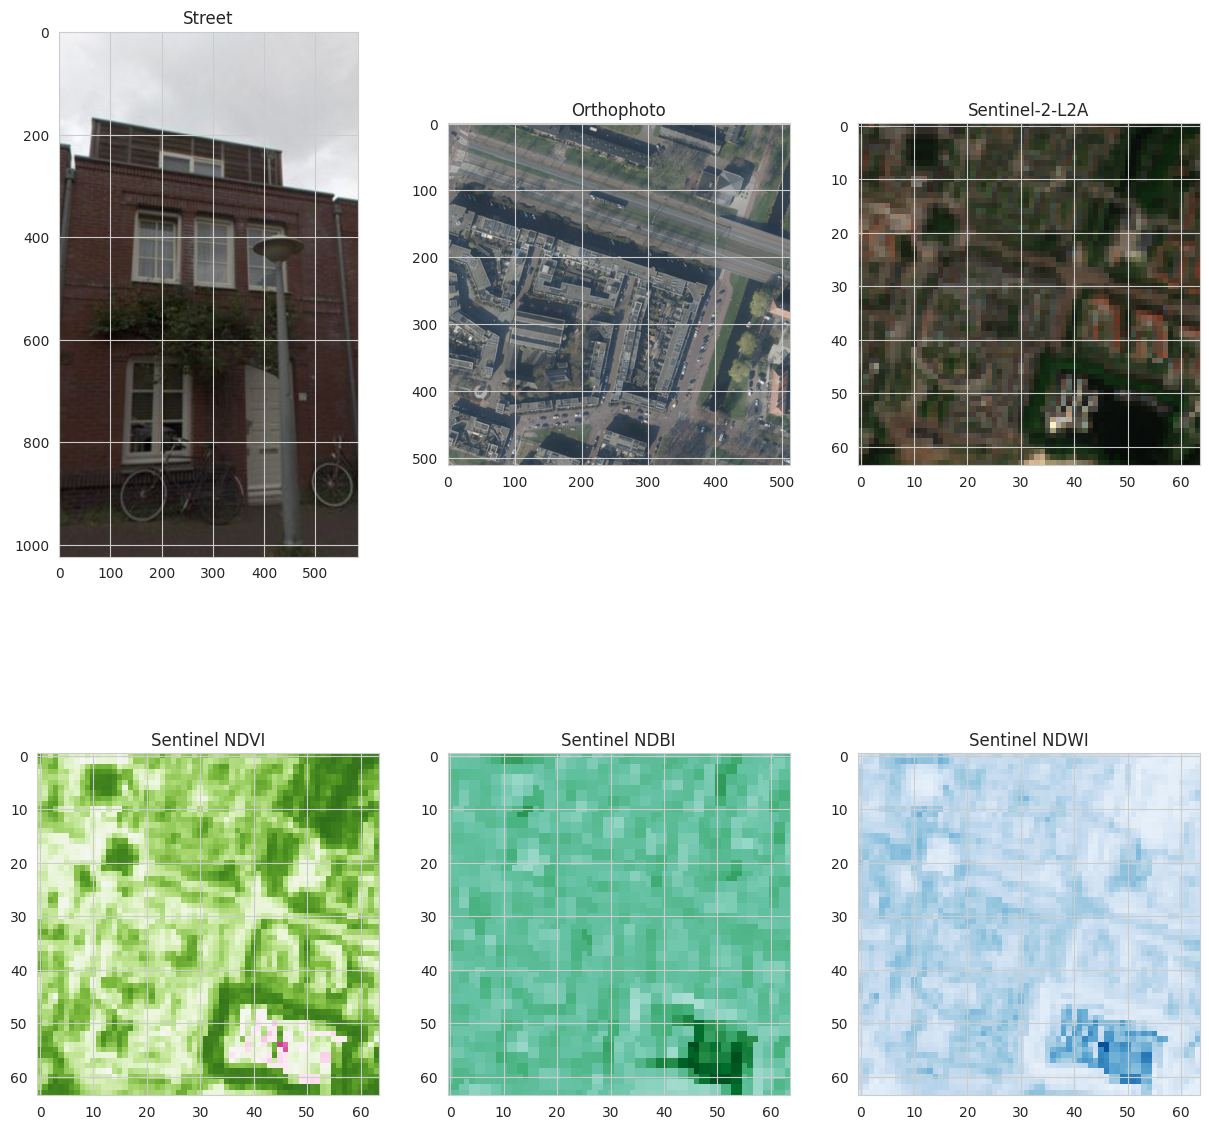

In [61]:
pid = np.random.choice(sub_df['pid'])
print(pid)

# Choose a building by pid:
#pid = '9hqfyzkkrh'

street = plt.imread(f"{train_path}{pid}/street.jpg")
orthophoto = plt.imread(f"{train_path}{pid}/orthophoto.tif")
s2 = rasterio.open(f"{train_path}{pid}/s2_l2a.tif").read()
s2 = np.transpose(s2,[1,2,0])

# calculate normalized indices
ndvi = (s2[:,:,7] - s2[:,:,3]) / (s2[:,:,7] + s2[:,:,3])

# Default rendering is Normalized Difference Built-Up Index computed as SWIR(Band11)-NIR(Band8)/ SWIR(Band11)+NIR(Band8)
ndbi = (s2[:,:,10] - s2[:,:,7]) / (s2[:,:,10] + s2[:,:,7])

# water index
# Sentinel-2 NDWI = (B03 - B08) / (B03 + B08)
ndwi = (s2[:,:,2] - s2[:,:,7]) / (s2[:,:,2] + s2[:,:,7])

print("Image dimensions:")
print(f"street view: {street.shape}" )
print(f"orthophoto: {orthophoto.shape}" )
print(f"Sentinel 2: {s2.shape}" )
print()
print(f"Label:\n {train_df.loc[train_df['pid']==pid][['pid', 'label']]}")

# Show the 3 modalities - street view, orthophoto and Seninel-2

fig, axs = plt.subplots(figsize=(15, 15), nrows=2, ncols = 3)
axs = axs.flatten()
axs[0].imshow(street)
axs[1].imshow(orthophoto)
axs[2].imshow(s2[...,[3,2,1]]*3e-4)
axs[3].imshow(ndvi, cmap="PiYG", vmin=-1, vmax=+1)
axs[4].imshow(ndbi, cmap="BuGn", vmin=-1, vmax=+1)
axs[5].imshow(ndwi, cmap="Blues", vmin=-1, vmax=+1)

axs[0].set_title("Street")
axs[1].set_title("Orthophoto")
axs[2].set_title("Sentinel-2-L2A");
axs[3].set_title("Sentinel NDVI")
axs[4].set_title("Sentinel NDBI")
axs[5].set_title("Sentinel NDWI")

plt.show()

In [64]:
country_ids = train_df['country_id'].unique()
country_ids

array(['QCD', 'PNN', 'HUN', 'FMW', 'EMA', 'NEA'], dtype=object)

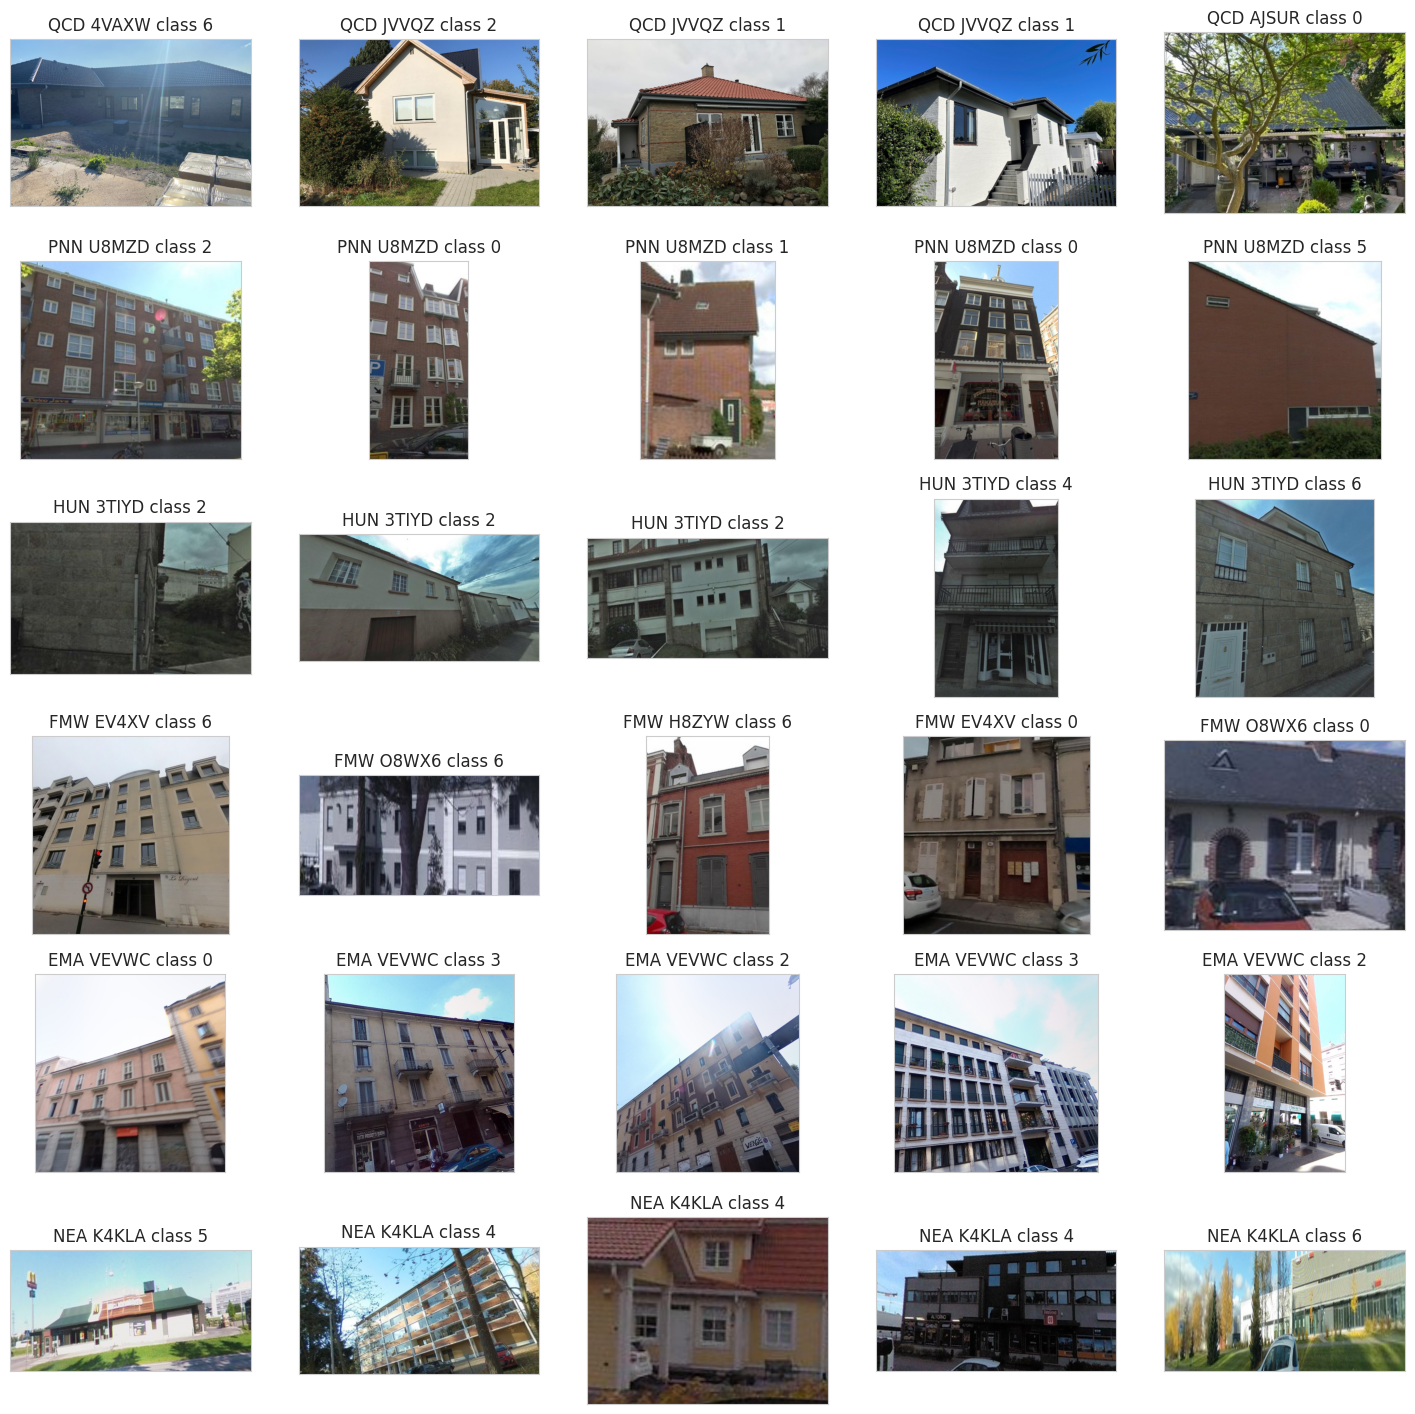

In [82]:
fig, ax = plt.subplots(6, 5, figsize=(18, 18))

for i, cid in enumerate(country_ids):
    pids = np.random.choice(train_df[train_df['country_id'] == cid]['pid'], size=5, replace=False)
    for j, pid in enumerate(pids):
        street = plt.imread(f"{train_path}{pid}/street.jpg")
        tmp = train_df.loc[train_df['pid'] == pid]
        ttl = f"{tmp['country_id'].values[0]} {tmp['city_id'].values[0]} class {tmp['label'].values[0]}"
        
        ax[i,j].imshow(street)
        ax[i,j].grid(False)
        ax[i,j].set_xticks([])
        ax[i,j].set_yticks([])
        ax[i,j].set_title(ttl)

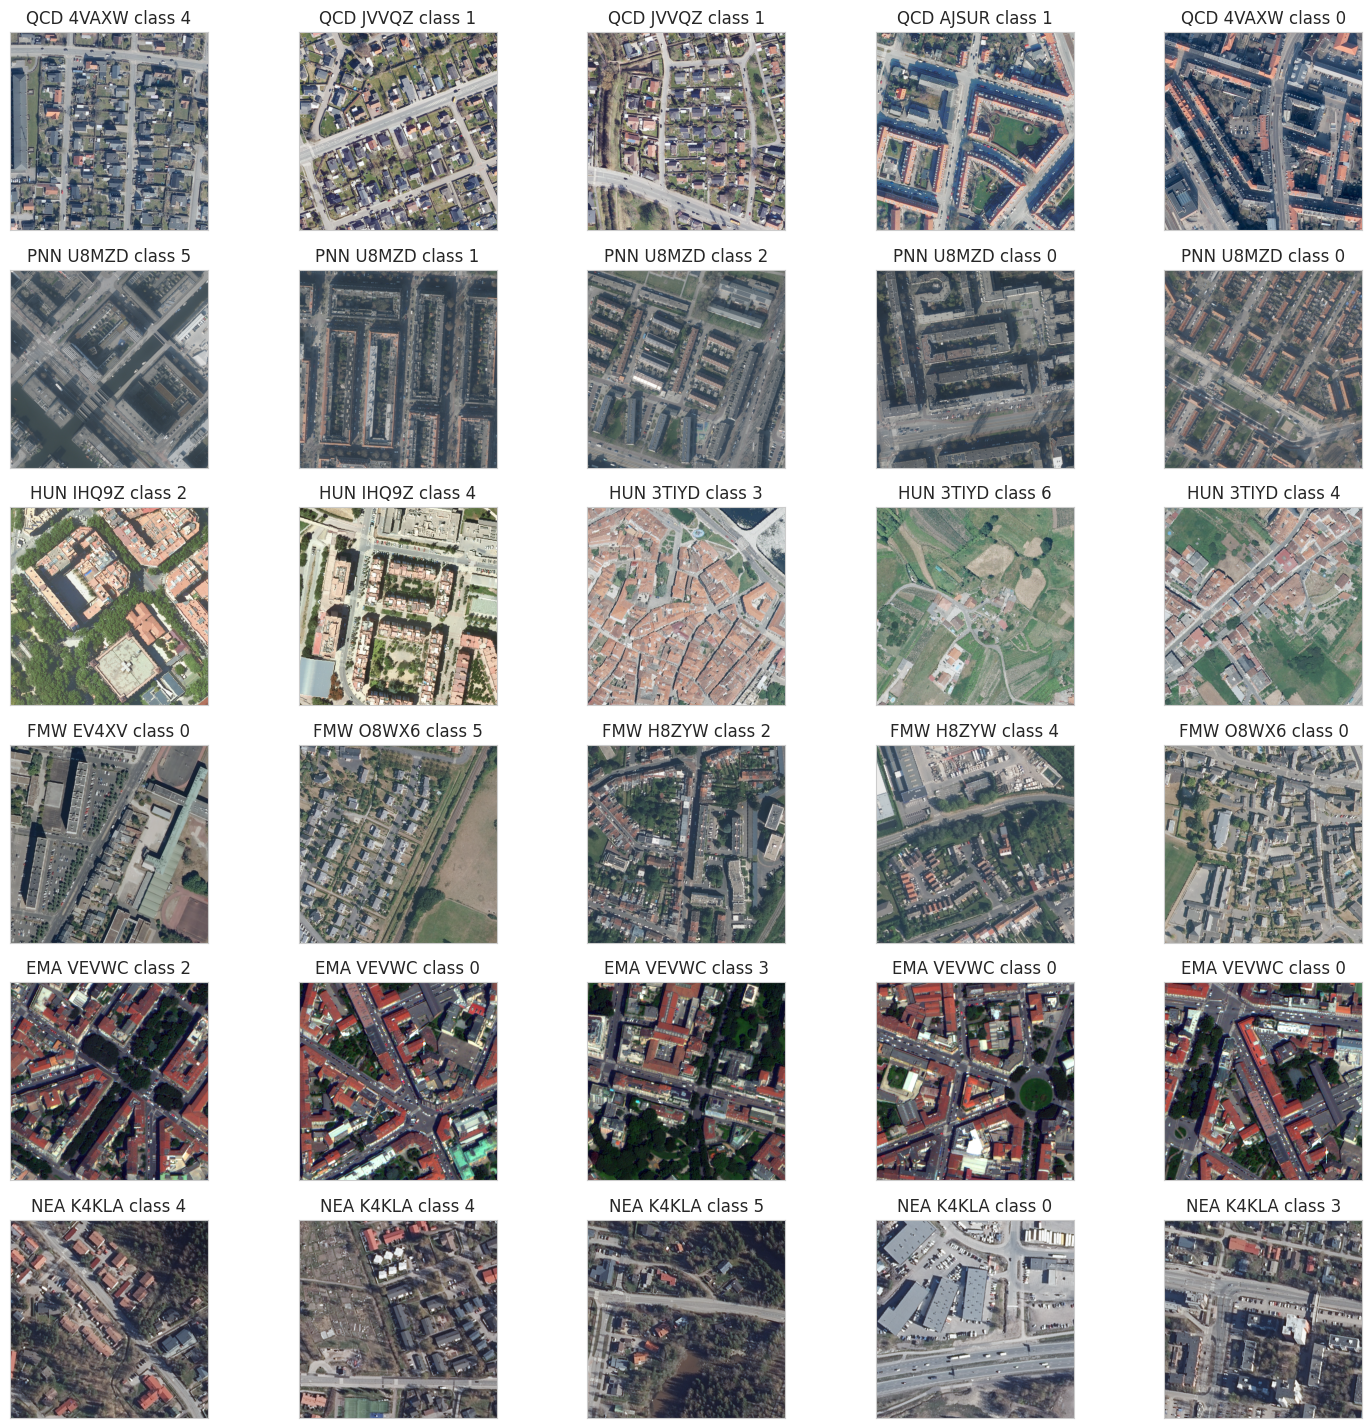

In [83]:
fig, ax = plt.subplots(6, 5, figsize=(18, 18))

for i, cid in enumerate(country_ids):
    pids = np.random.choice(train_df[train_df['country_id'] == cid]['pid'], size=5, replace=False)
    for j, pid in enumerate(pids):
        orthophoto = plt.imread(f"{train_path}{pid}/orthophoto.tif")
        tmp = train_df.loc[train_df['pid'] == pid]
        ttl = f"{tmp['country_id'].values[0]} {tmp['city_id'].values[0]} class {tmp['label'].values[0]}"
        
        ax[i,j].imshow(orthophoto)
        ax[i,j].grid(False)
        ax[i,j].set_xticks([])
        ax[i,j].set_yticks([])
        ax[i,j].set_title(ttl)

In [62]:
assert False

AssertionError: 

In [ ]:
import optuna

In [ ]:
city_ids = train_df['city_id'].unique()
ix = np.arange(len(city_ids))
city_ids, len(city_ids)


In [ ]:
country_ids = train_df['country_id'].unique()
ix = np.arange(len(country_ids))
country_ids, len(country_ids)


In [ ]:
train_df.groupby(['country_id', 'city_id'])['label'].mean()

In [ ]:
def objective(trial):
    
    shuffles = trial.suggest_int('shuffles', 0, 10000)
    
    ix = np.arange(len(city_ids))
    for i in range(shuffles):
        np.random.seed(404)
        np.random.shuffle(ix)
    
    lens = []
    lbls = []
    
    for k in range(5):
        subix = city_ids[ix][3*k:3*k+3]
        s = f"city_id in ['{subix[0]}', '{subix[1]}', '{subix[2]}']"
        s2 = f"city_id not in ['{subix[0]}', '{subix[1]}', '{subix[2]}']"
        v_split = train_df.query(s)    
        t_split = train_df.query(s2)
        
        lens.append(len(t_split))
        
        # label distribution
        lbls.append(t_split.groupby(['country_id', 'city_id'])['label'].mean().std())
        
    #print(lbls)
    
    alpha1 = 1.0
    alpha2 = 1.0
        
    return alpha1 * np.std(lens) / np.mean(lens) + alpha2 * np.std(lbls) / np.mean(lbls)

In [ ]:
study = optuna.create_study()
study.optimize(objective, n_trials=100)

In [ ]:
ix = np.arange(len(city_ids))
for i in range(study.best_params['shuffles']):
    np.random.seed(404)
    np.random.shuffle(ix)

In [ ]:
vc = {}

for k in range(5):
    subix = city_ids[ix][3*k:3*k+3]
    print(subix)
    s = f"city_id in ['{subix[0]}', '{subix[1]}', '{subix[2]}']"
    s2 = f"city_id not in ['{subix[0]}', '{subix[1]}', '{subix[2]}']"
    v_split = train_df.query(s)    
    t_split = train_df.query(s2)
    
    v_split['fold'] = k
    t_split['fold'] = k
    
    print(len(t_split))
    print(len(v_split))
    
    vc[f'fold_{k}'] = t_split['label'].value_counts().to_frame().reset_index().sort_values('label')['count'].values
    
    #v_split.to_csv(f'split_valid_{k}.csv', index=False)
    #t_split.to_csv(f'split_train_{k}.csv', index=False)    

In [ ]:
vc['label'] = list(range(7))
ldf = pd.DataFrame(vc)

In [ ]:
sns.barplot(data=ldf.melt(id_vars='label'), x='label', y='value', hue='variable')